# Stock Price Prediction using LSTM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import kagglehub
from kagglehub import KaggleDatasetAdapter

/Users/shresthpanigrahi/Desktop/Corizio/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load dataset
file_path = "individual_stocks_5yr/individual_stocks_5yr/AAPL_data.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "camnugent/sandp500",
    file_path,
)

print(df.head())
print(df.shape)

/var/folders/1b/vvxjmflx2h9d60lg1xxvg1p00000gn/T/ipykernel_21676/4064551478.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Download already complete (67207 bytes).


         date     open     high      low    close     volume  Name
0  2013-02-08  67.7142  68.4014  66.8928  67.8542  158168416  AAPL
1  2013-02-11  68.0714  69.2771  67.6071  68.5614  129029425  AAPL
2  2013-02-12  68.5014  68.9114  66.8205  66.8428  151829363  AAPL
3  2013-02-13  66.7442  67.6628  66.1742  66.7156  118721995  AAPL
4  2013-02-14  66.3599  67.3771  66.2885  66.6556   88809154  AAPL
(1259, 7)


In [3]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.sort_index()
print(df.head())

               open     high      low    close     volume  Name
date                                                           
2013-02-08  67.7142  68.4014  66.8928  67.8542  158168416  AAPL
2013-02-11  68.0714  69.2771  67.6071  68.5614  129029425  AAPL
2013-02-12  68.5014  68.9114  66.8205  66.8428  151829363  AAPL
2013-02-13  66.7442  67.6628  66.1742  66.7156  118721995  AAPL
2013-02-14  66.3599  67.3771  66.2885  66.6556   88809154  AAPL


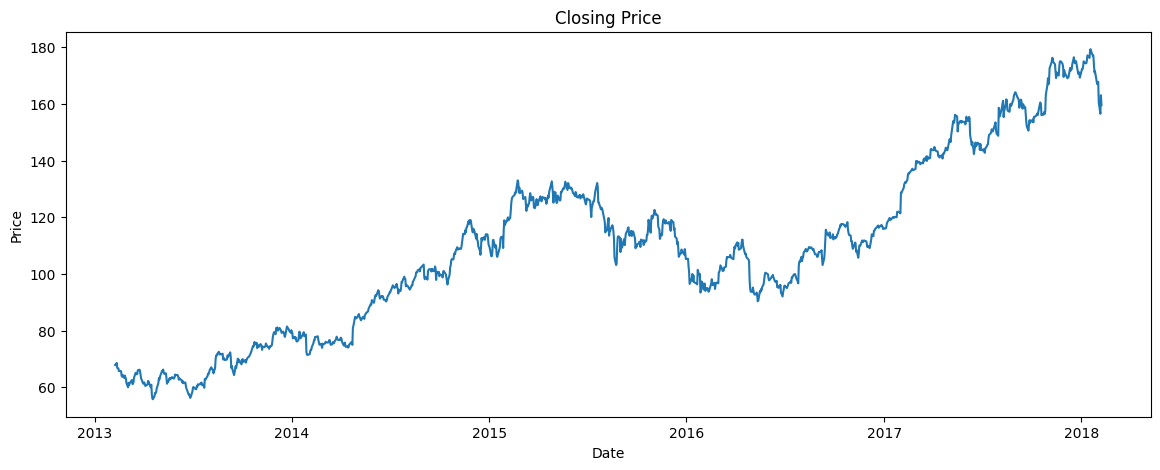

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df['close'])
plt.title('Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [5]:
# scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(df['close'].values.reshape(-1, 1))

In [6]:
# create sequences
window = 60

X = []
y = []
for i in range(window, len(scaled)):
    X.append(scaled[i-window:i, 0])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)

# reshape for LSTM [samples, timesteps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)
print(X.shape, y.shape)

(1199, 60, 1) (1199,)


In [7]:
# train test split
split = int(len(X) * 0.8)

X_train = X[:split]
y_train = y[:split]
X_test = X[split:]
y_test = y[split:]

print(X_train.shape, X_test.shape)

(959, 60, 1) (240, 60, 1)


In [8]:
# build model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/Users/shresthpanigrahi/Desktop/Corizio/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20


 1/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 0.1856

 5/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1464

 9/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1157

13/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0972

...

17/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0015

21/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0015

25/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0015

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0015

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015 - val_loss: 0.0012


In [10]:
# predict
preds = model.predict(X_test)

# inverse transform
preds = scaler.inverse_transform(preds)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


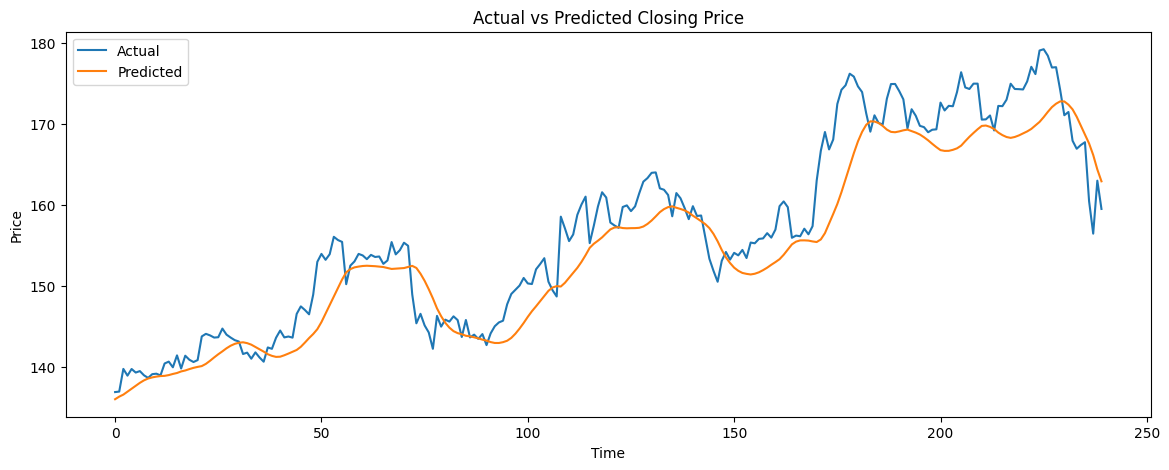

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(actual, label='Actual')
plt.plot(preds, label='Predicted')
plt.title('Actual vs Predicted Closing Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [12]:
rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

RMSE: 4.336983450335262
MAE: 3.351631663004557
